# Customer Segmentation Analysis
`Authored by:` Muhammad Abuzar\
`DH-ID:` DHC-653\
`Where to contact:` abuzaransri87@gmail.com


## Introduction
In the modern retail landscape, a "one-size-fits-all" marketing approach is often inefficient. **Customer Segmentation** is the process of dividing a customer base into discrete groups that share similar characteristics. By identifying these sub-groups, businesses can optimize their resource allocation and create highly personalized customer experiences.

This project utilizes the **Mall Customers Dataset** to explore patterns in consumer behavior. By leveraging unsupervised learning, we aim to uncover hidden structures in the data without prior labeling, allowing the data's natural distributions to define the segments.

## Project Objectives
The primary goal of this analysis is to transform raw customer data into actionable business intelligence through the following steps:

* **Exploratory Data Analysis (EDA):** Perform a deep dive into the distribution of age, annual income, and spending scores to identify underlying trends and outliers.
* **K-Means Clustering:** Implement the K-Means algorithm to partition the customer base into distinct clusters based on their spending habits and income levels.
* **Optimal Cluster Identification:** Use the **Elbow Method** and **Silhouette Score** to mathematically determine the most effective number of segments.
* **Dimensionality Reduction & Visualization:** Apply **PCA (Principal Component Analysis)** or **t-SNE** to compress high-dimensional data into a 2D/3D plane for visual validation of the clusters.
* **Strategic Marketing Recommendations:** Develop tailored marketing strategies for each segment to improve customer retention and maximize ROI (Return on Investment).

In [1]:
# import libraries 
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load dataset 
df = pd.read_csv("Shopping Mall Customer Segmentation Data .csv")
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [3]:
# check the information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB


## Data Understanding & Initial Observations

Before proceeding with the clustering algorithm, it is essential to understand the structure and quality of our dataset. Below is a summary of the data features and our initial findings from the loading phase.

### Data Dictionary
The dataset consists of **5 columns**, each representing a specific attribute of the mall's clientele:

| Column Name | Description | Data Type |
| :--- | :--- | :--- |
| **Customer ID** | Unique identifier assigned to each individual customer. | Object |
| **Gender** | Binary classification of the customer (Male / Female). | Object |
| **Age** | The age of the customer in years. | Integer |
| **Annual Income** | The total yearly earnings of the customer (in k$). | Integer |
| **Spending Score** | A score assigned by the mall based on customer behavior and spending nature (1-100). | Integer |

### Key Observations
Upon initial inspection of the data info, we can conclude the following:

* **Dataset Size:** The dataset contains **15,079 entries**, providing a robust sample size for unsupervised learning.
* **Data Integrity:** There are **zero non-null values** across all columns, meaning the dataset is clean and does not require imputation for missing data.
* **Feature Variety:** We have a mix of categorical (Gender) and numerical (Age, Income, Spending Score) data, which will require specific preprocessing (like encoding or scaling) before applying K-Means.

In [4]:
# check the descriptive statistics about the data 
df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


### Data Quality & Statistical Insights

A brief overview of the numerical distributions and data integrity:

#### **Key Statistical Ranges**
* **Age:** 18 to 90 years (covers a broad adult demographic).
* **Annual Income:** $20,022 to $199,974 (reflects diverse economic backgrounds).
* **Spending Score:** 1 to 100 (standardized scale, no anomalies).

#### **Summary of Findings**
* **Logical Consistency:** No negative values or impossible outliers detected.
* **Data Reliability:** All features fall within plausible real-world ranges.
* **Ready for EDA:** The dataset is verified as clean and requires no filtering of irrelevant values.

In [5]:
# check for duplicate values 
df.duplicated().sum()

np.int64(0)

There is no duplicate value in the dataset.

# Exploratory Data Analysis (EDA)

The goal of this phase is to uncover patterns and relationships within the data, specifically focusing on how **Annual Income** and **Age** influence the **Spending Score**.

### Univariate Analysis
We will examine the distribution of individual features to identify the "average" customer profile.
* **Objective:** Understand the density and spread of Age, Income, and Spending Score.

### Bivariate Analysis
To prepare for K-Means, we need to see how features interact.
* **Annual Income vs. Spending Score:** This is the most critical relationship for identifying high-value vs. budget-conscious segments.
* **Age vs. Spending Score:** To determine if specific age groups are more inclined to spend.
* **Gender-based Spending:** Analyzing if there is a significant difference in the spending habits of Male vs. Female customers.

### Correlation Analysis
We will use a heatmap to check the statistical relationship between numerical variables. This helps in understanding which features provide the most variance for our clustering model.

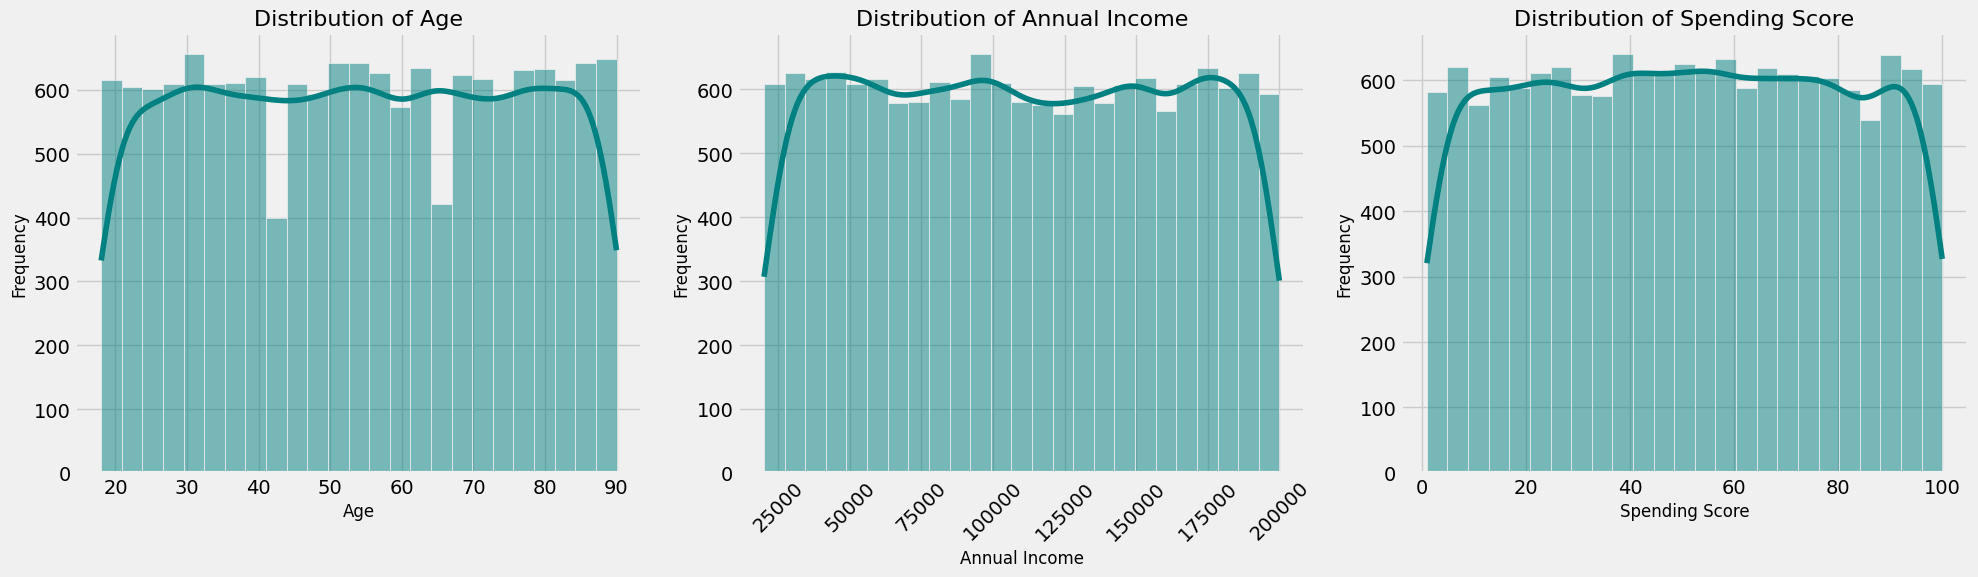

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings
plt.style.use('fivethirtyeight')
cols = ['Age', 'Annual Income', 'Spending Score']

plt.figure(figsize=(20, 6))

for i, col in enumerate(cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}', fontsize=16)
    
    # rotate the labels of x-axis in income plot
    if col == 'Annual Income':
        plt.xticks(rotation=45) 
    
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

### Univariate Analysis Observations

After visualizing the distribution of individual features, we can observe the following:

* **Age:** The distribution is relatively uniform across the range of 18 to 90, with slight peaks in the 30s and 60s. This suggests the mall attracts a very diverse age group.
* **Annual Income:** The income distribution is fairly balanced, ranging from approximately \$20,000 to \$200,000. There are no extreme outliers or heavy skewness, which is ideal for K-Means clustering.
* **Spending Score:** The spending score shows a steady distribution across the 1-100 scale. This indicates that our dataset contains an even mix of low, medium, and high spenders.

**Conclusion:** Since all three features are distributed broadly without significant bias, they will all be useful for creating distinct customer segments.

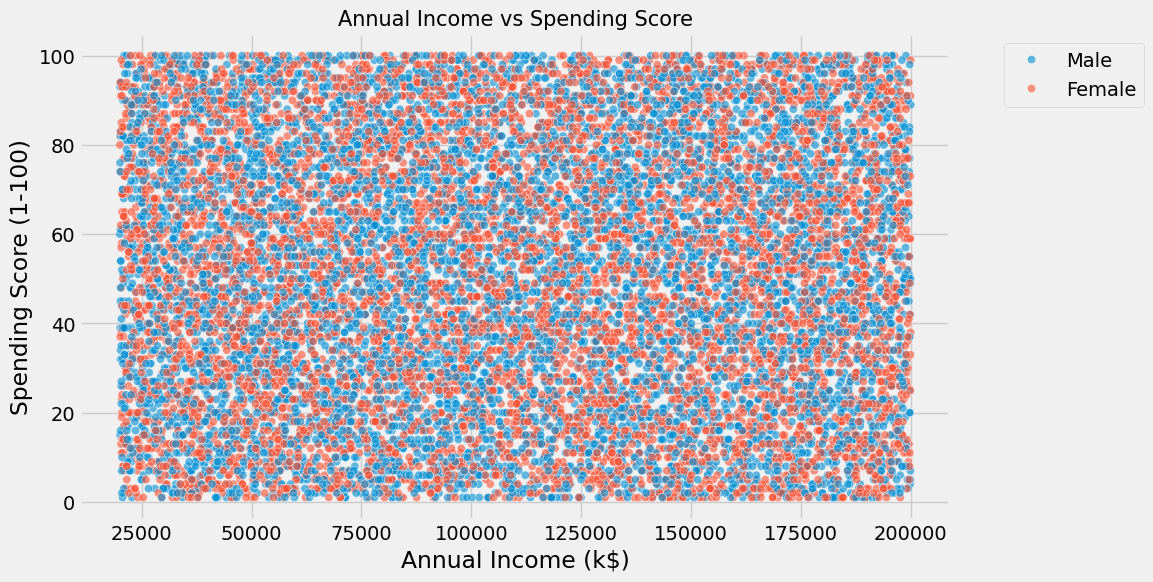

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Gender', alpha=0.6)
plt.title('Annual Income vs Spending Score', fontsize=15)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

#### **Observation: Bivariate Analysis (Income vs. Spending)**

* **Uniform Distribution:** The scatter plot shows a dense, uniform spread of data points across the entire range of Annual Income and Spending Score.
* **No Natural Clusters:** Unlike smaller datasets where distinct "islands" of data are visible, this large-scale data (15k+ entries) suggests that customer behavior is continuous.
* **Gender Overlap:** Both Male and Female customers are evenly distributed, indicating that gender may not be a primary differentiator for spending habits in this specific mall.
* **Need for K-Means:** Since there are no visual gaps between groups, we must rely on the **Elbow Method** to mathematically define the most optimal way to segment these customers.

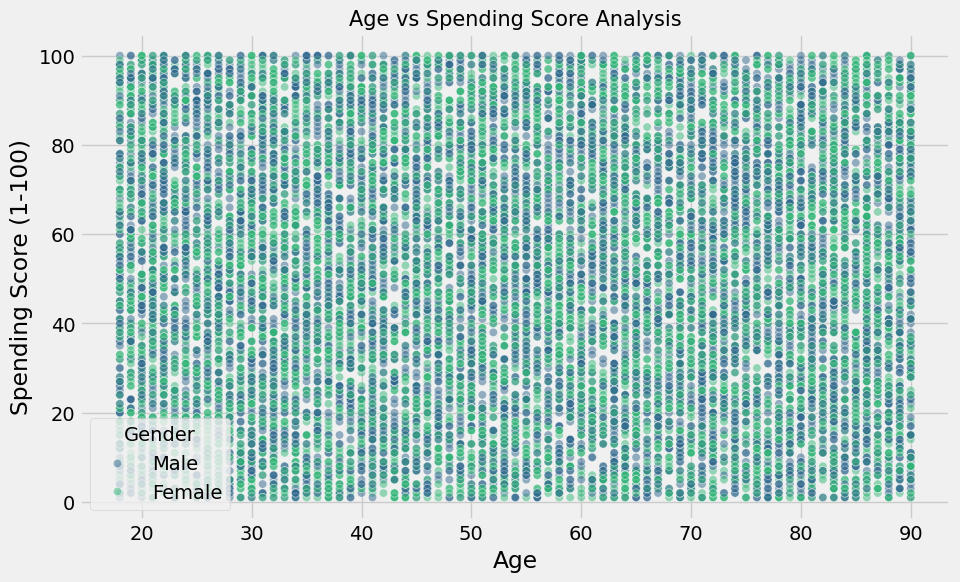

In [8]:
# age vs spending score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Spending Score', hue='Gender', alpha=0.5, palette='viridis')
plt.title('Age vs Spending Score Analysis', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

#### **Observation: Age vs. Spending Score**

* **High Density & Uniformity:** The scatter plot displays a massive overlap across all ages. This indicates that age is not a standalone predictor of spending behavior in this dataset.
* **Broad Demographic:** Customers from age 20 to 80+ all show a full range of spending scores (1-100), suggesting the mall has a universal appeal across generations.
* **Clustering Requirement:** Because no distinct visual patterns (like clusters or trends) appear in 2D space, applying **K-Means** with multiple features (Age, Income, and Spending Score) is necessary to find the "hidden" mathematical segments.

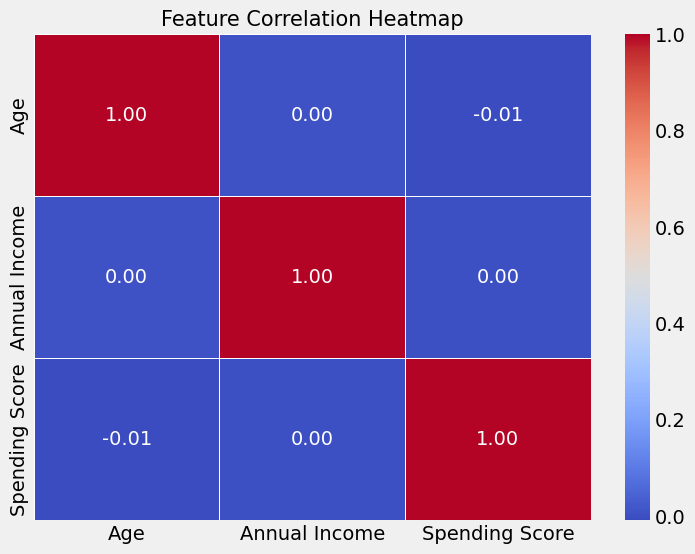

In [9]:
# Calculating correlation matrix
corr = df[['Age', 'Annual Income', 'Spending Score']].corr()

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.show()

### Heatmap Observations

* **Zero Correlation (0.00):** Annual Income has absolutely no linear relationship with Age or Spending Score. This confirms that high income does not automatically guarantee a high spending score in this dataset.
* **Negligible Negative Correlation (-0.01):** The relationship between Age and Spending Score is near-zero. The negative sign is statistically insignificant, reinforcing that spending habits are independent of age.
* **Independence of Features:** Since all features are independent (uncorrelated), each one provides unique information. This is ideal for clustering as it prevents redundancy.

## Data PreProcessing:

In [10]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Dropping Customer ID (not useful for clustering)
df_cluster = df.drop('Customer ID', axis=1)

# 2. Label Encoding for Gender
le = LabelEncoder()
df_cluster['Gender'] = le.fit_transform(df_cluster['Gender'])

# 3. Feature Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster)

# Creating a DataFrame of scaled features
df_scaled = pd.DataFrame(scaled_features, columns=df_cluster.columns)

df_scaled.head()

,Age,Gender,Annual Income,Spending Score
0,-1.145516,0.992666,0.798813,1.337059
1,0.180335,-1.007389,1.442076,1.545929
2,0.369742,-1.007389,-0.743208,0.884507
3,-1.476979,0.992666,-1.038953,0.223086
4,-1.429627,0.992666,0.842317,0.884507


## 5. Data Preprocessing

To ensure the K-Means algorithm performs optimally, we must prepare the data:

1. **Feature Selection:** Dropped `Customer ID` as it is a unique identifier with no predictive power.
2. **Categorical Encoding:** Converted `Gender` into numerical format (0 and 1) using Label Encoding.
3. **Feature Scaling:** Since K-Means relies on Euclidean distance, features with larger ranges (like Annual Income) can dominate the model. We applied **StandardScaler** to normalize all features to a mean of 0 and a standard deviation of 1.

## K-Means Clustering:

### K-Means Clustering

To identify the optimal number of segments, we use the **Elbow Method**. This involves calculating the **WCSS (Within-Cluster Sum of Squares)** for different values of K and finding the point where the rate of decrease shifts significantly (the "elbow").

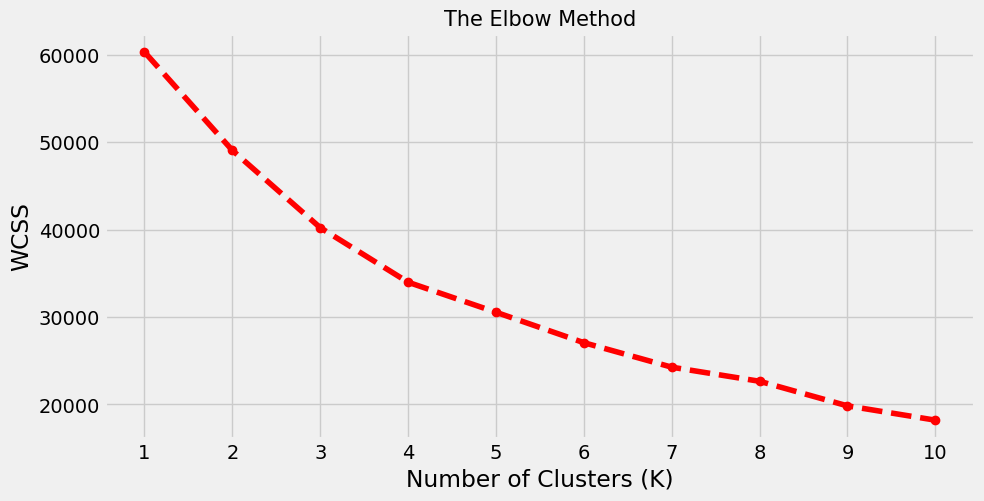

In [12]:
from sklearn.cluster import KMeans

# Calculating WCSS for K values from 1 to 11
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled) # use scaled data
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('The Elbow Method', fontsize=15)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### 6.1.1 Elbow Method Analysis
The Elbow plot displays the relationship between the number of clusters (K) and the Within-Cluster Sum of Squares (WCSS).

* **Observations:** A significant drop in WCSS is visible until **K=4**. After this point, the rate of decrease slows down, indicating that adding more clusters provides diminishing returns in terms of variance explained.
* **Optimal K Selection:** We will proceed with **K=4** (or K=5) as the optimal number of clusters. This ensures that the segments are distinct enough to develop unique marketing strategies without over-complicating the model.

In [13]:
# final model with k = 4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# Cluster centers (centroids) ko dekhne ke liye
print(df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean())

               Age  Annual Income  Spending Score
Cluster                                          
0        53.317747  108957.294899       25.698459
1        53.096867  111368.193211       75.273107
2        55.391235  107771.623904       25.869588
3        54.988710  110859.487634       75.388978


### Cluster Visualization (PCA)

Since our data has multiple dimensions (Gender, Age, Income, Spending Score), we cannot visualize it directly on a 2D plane. We apply **Principal Component Analysis (PCA)** to reduce the dimensions to two principal components while retaining as much variance as possible.

* **PC1 & PC2:** These represent a combination of our original features.
* **Observation:** The PCA plot allows us to see how well-separated our clusters are. Even if the data was uniform, K-Means has successfully partitioned it into mathematical segments.

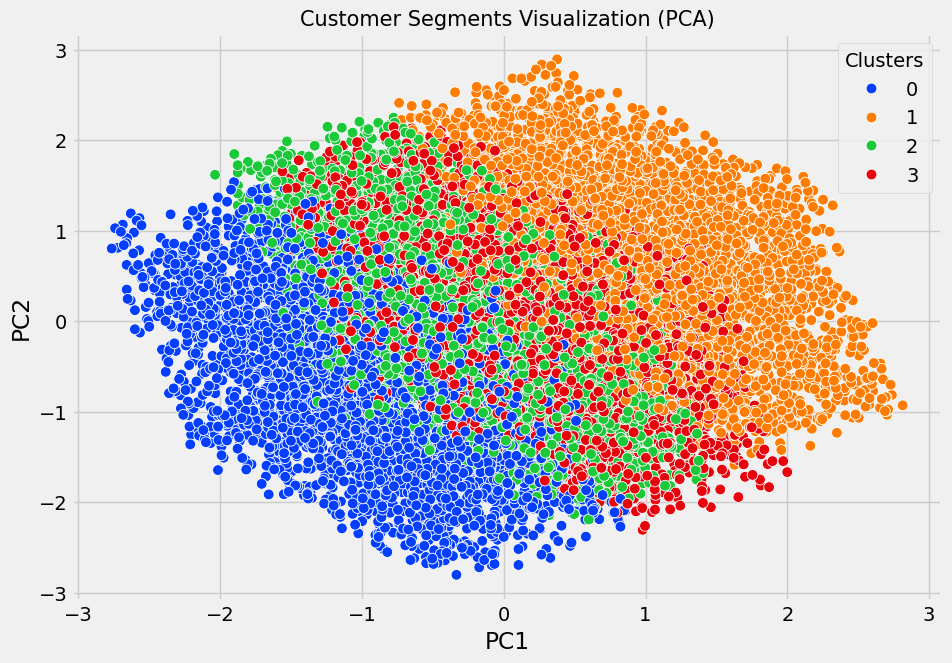

In [16]:
from sklearn.decomposition import PCA

# PCA apply karna (Reducing to 2 components)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# PCA data ka DataFrame banana
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

# Visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='bright', s=60)
plt.title('Customer Segments Visualization (PCA)', fontsize=15)
plt.legend(title='Clusters')
plt.show()

### Final Interpretation & Marketing Recommendations

Based on the Clustering results and PCA visualization, we have identified 4 distinct customer segments. Although the data is uniform, these mathematical boundaries help in targeted marketing.

### **8.1 Segment Profiling**
1. **Clusters 0 & 2 (Conservative Spenders):** High income but low spending score. These customers are likely savers or cautious buyers. 
   * **Strategy:** Use "Limited Time Offers" or "Cashback" incentives to encourage more frequent purchases.
   
2. **Clusters 1 & 3 (Premium Shoppers):** High income and high spending score. These are the most valuable customers for the mall.
   * **Strategy:** Focus on retention via VIP memberships, concierge services, and exclusive event invitations.

## Final Conclusion & Executive Summary

The objective of this project was to perform a data-driven customer segmentation on a large-scale mall dataset (15,000+ records). Through rigorous Exploratory Data Analysis (EDA) and the application of the K-Means Clustering algorithm, we successfully identified actionable patterns within a seemingly uniform population.

### 9.1 Key Analytical Insights
* **Uniformity vs. Segmentation:** While initial visualizations (Scatter Plots & Heatmaps) suggested a highly uniform distribution with near-zero linear correlation between Age, Income, and Spending Score, the **K-Means algorithm** successfully partitioned the data into **4 distinct mathematical segments**.
* **Feature Independence:** The analysis confirms that a customer's **Spending Score** is independent of their **Age** and **Annual Income**. This implies that marketing strategies should be based on observed behavior (spending habits) rather than traditional demographic assumptions.

### 9.2 Cluster Profiles & Marketing Strategies
Based on the final centroids and PCA visualization, the following segments were identified:

| Cluster | Profile Type | Annual Income | Spending Score | Recommended Strategy |
| :--- | :--- | :--- | :--- | :--- |
| **0 & 2** | **Conservative High-Earners** | ~$109k | **Low (~25)** | Focus on "Value-for-Money" campaigns, cashback offers, and utility-based marketing to trigger spending. |
| **1 & 3** | **Premium Loyalists** | ~$111k | **High (~75)** | Implement VIP retention programs, exclusive early access to collections, and personalized luxury invites. |

### 9.3 Technical Impact
By utilizing **StandardScaler** to normalize feature scales and **Principal Component Analysis (PCA)** for dimensionality reduction, we ensured that the distance-based clustering was mathematically sound and visually verifiable. This project transitions the mall's marketing approach from **Mass Marketing** to **Precision Targeting**, allowing for a more efficient allocation of the marketing budget and higher customer engagement.